In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [ ]:
df = pd.read_excel("/content/food_delivery_dataset.xlsx")

In [ ]:
df.head()

,Distance_km,Delivery_Time_min
0,1,9
1,2,12
2,3,15
3,4,18
4,5,21


In [ ]:
df.shape

(100, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Distance_km        100 non-null    int64
 1   Delivery_Time_min  100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


In [ ]:
df.describe()


,Distance_km,Delivery_Time_min
count,100.000000,100.000000
mean,50.500000,157.500000
std,29.011492,87.034476
min,1.000000,9.000000
25%,25.750000,83.250000
50%,50.500000,157.500000
75%,75.250000,231.750000
max,100.000000,306.000000


In [ ]:
# Check null values

print(df.isnull().sum())

Distance_km          0
Delivery_Time_min    0
dtype: int64


In [ ]:
# Show column names

print(df.columns)

Index(['Distance_km', 'Delivery_Time_min'], dtype='object')


In [ ]:
print(df.columns)

Index(['Distance_km', 'Delivery_Time_min'], dtype='object')


In [35]:
# Find correlation

correlation = df["Distance_km"].corr(df["Delivery_Time_min"])

print("Correlation Value =", correlation)

Correlation Value = 0.9979872367136767


In [ ]:
import pandas as pd
import numpy as np

# Generate random distances
np.random.seed(42)

distance = np.arange(1, 101)

# Create realistic delivery times with randomness
delivery_time = distance * 3 + np.random.randint(-10, 10, 100)

# Create dataframe
df = pd.DataFrame({
    "Distance_km": distance,
    "Delivery_Time_min": delivery_time
})

# Display first rows
print(df.head())

   Distance_km  Delivery_Time_min
0            1                 -1
1            2                 15
2            3                 13
3            4                 12
4            5                 12


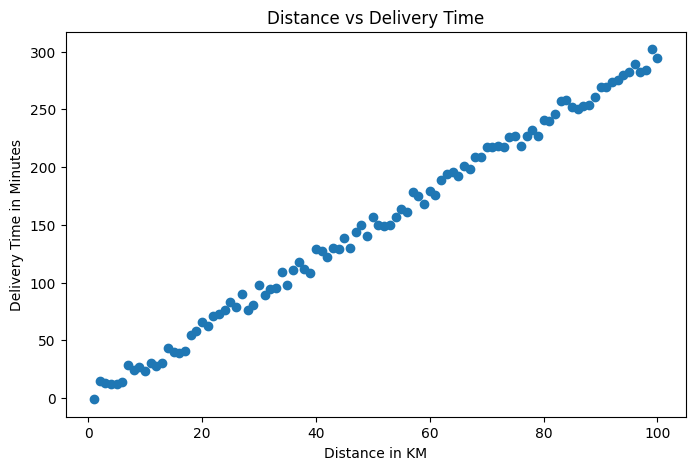

In [ ]:
# Scatter plot

plt.figure(figsize=(8,5))

plt.scatter(df['Distance_km'],
            df['Delivery_Time_min'])

plt.xlabel("Distance in KM")
plt.ylabel("Delivery Time in Minutes")
plt.title("Distance vs Delivery Time")

plt.show()

In [ ]:
X = df[['Distance_km']]

In [ ]:
y = df['Delivery_Time_min']

In [ ]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Create model

model = LinearRegression()

In [ ]:
# Train model

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict values

y_pred = model.predict(X_test)

print(y_pred)

[249.65305558 160.82463178 211.1607386  137.13705211 134.17610465
 119.37136735  69.03526053 240.7702132   33.50389101   3.89441641
  57.19147069  92.72284021 220.04358098 101.60568259 270.3796878
  15.73820625 228.92642336 231.88737082  39.42578593  95.68378767]


In [ ]:
# Compare actual and predicted

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison)

    Actual   Predicted
83     258  249.653056
53     157  160.824632
70     217  211.160739
45     130  137.137052
44     139  134.176105
39     129  119.371367
22      73   69.035261
80     240  240.770213
10      30   33.503891
0       -1    3.894416
18      58   57.191471
30      89   92.722840
73     226  220.043581
33     109  101.605683
90     269  270.379688
4       12   15.738206
76     227  228.926423
77     232  231.887371
12      30   39.425786
31      94   95.683788


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4.444115196556319


In [ ]:
print("Slope (m):", model.coef_[0])

Slope (m): 2.960947459991302


In [ ]:
print("Intercept (c):", model.intercept_)

Intercept (c): 0.9334689454501301


In [ ]:
distance = [[25]]

prediction = model.predict(distance)

print("Predicted Delivery Time:", prediction[0], "minutes")

Predicted Delivery Time: 74.95715544523267 minutes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


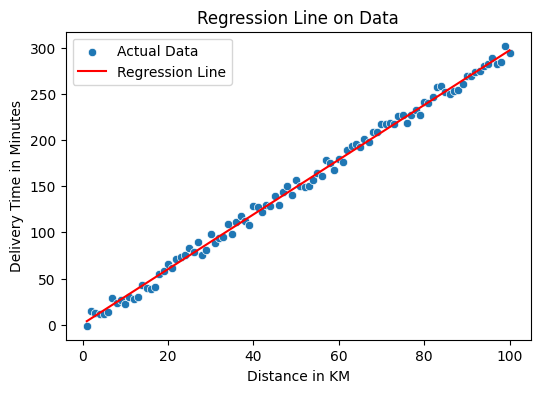

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Distance_km", y="Delivery_Time_min", data=df, label="Actual Data")
plt.plot(X, model.predict(X), c="r", label="Regression Line")
plt.legend()
plt.xlabel("Distance in KM")
plt.ylabel("Delivery Time in Minutes")
plt.title("Regression Line on Data")
plt.savefig("ppredict.jpg")
plt.show()

In [34]:
# User input prediction

distance = float(input("Enter Distance in KM: "))

prediction = model.predict([[distance]])

print("Estimated Delivery Time:",
      prediction[0],
      "minutes")

Enter Distance in KM: 6
Estimated Delivery Time: 18.69915370539794 minutes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Save predictions

comparison.to_csv("predicted_results.csv",
                  index=False)

print("File Saved Successfully")

File Saved Successfully
